# Compliance Risk Predictor - Logistic Regression Model

## Session 2 - Model Training and Evaluation

Key findings:
- Threshold tuned from 0.5 to 0.3 to reduce false negatives
- Recall on non-compliant devices improved from 0.26 to 0.71
- AUC: 0.69 - model performs meaningfully above random baseline
- app_install_failures is the strongest predictor of non-compliance
- All coefficients directionally consistent with Intune domain knowledge

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/sample/compliance_data.csv')
df.shape

(1000, 6)

In [3]:
df.head()

,days_since_sync,os_version_risk,failed_policy_count,app_install_failures,assigned_policy_count,is_non_compliant
0,8.5,1,2,1,14,1
1,1.8,0,2,3,13,0
2,10.8,0,4,0,3,1
3,11.7,0,2,0,15,0
4,0.0,0,2,0,3,0


In [4]:
X = df.drop('is_non_compliant', axis=1)
y = df['is_non_compliant']

print(X.shape)
print(y.shape)

(1000, 5)
(1000,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(800, 5)
(200, 5)
is_non_compliant
0    534
1    266
Name: count, dtype: int64
is_non_compliant
0    134
1     66
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.91      0.80       134
           1       0.59      0.26      0.36        66

    accuracy                           0.69       200
   macro avg       0.65      0.58      0.58       200
weighted avg       0.67      0.69      0.65       200



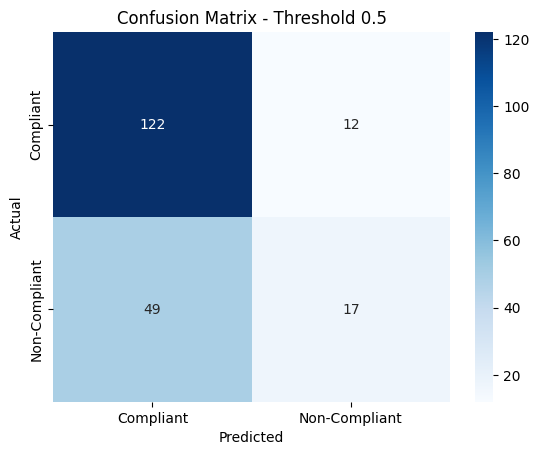

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compliant', 'Non-Compliant'],
            yticklabels=['Compliant', 'Non-Compliant'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Threshold 0.5')
plt.show()

In [10]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print(y_prob[:10])

[0.27151232 0.25428728 0.27934794 0.17689003 0.39124569 0.41370755
 0.30955033 0.29980706 0.17070619 0.64295133]


In [11]:
y_pred_tuned = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.79      0.52      0.63       134
           1       0.42      0.71      0.53        66

    accuracy                           0.58       200
   macro avg       0.60      0.62      0.58       200
weighted avg       0.67      0.58      0.60       200



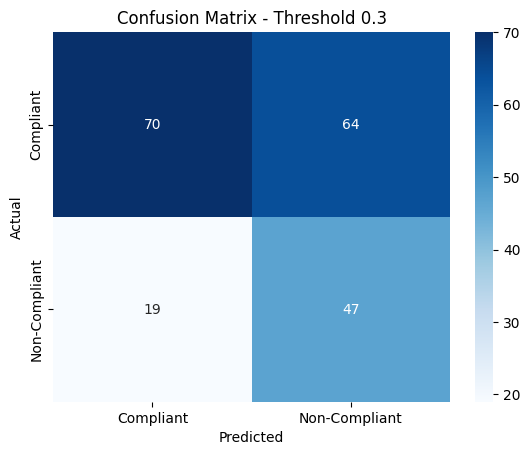

In [12]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Compliant', 'Non-Compliant'],
            yticklabels=['Compliant', 'Non-Compliant'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Threshold 0.3')
plt.show()

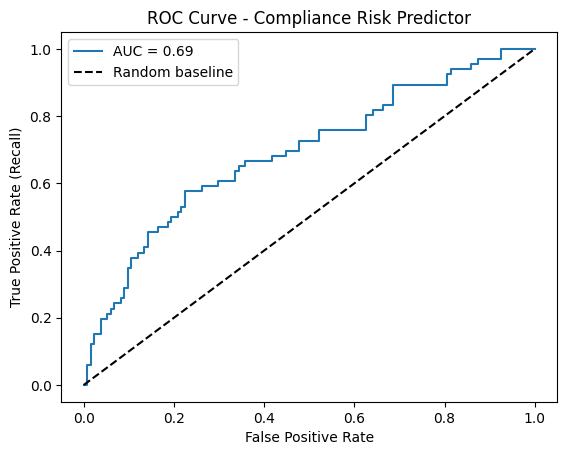

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Compliance Risk Predictor')
plt.legend()
plt.show()

In [14]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print(coef_df)

                 Feature  Coefficient
3   app_install_failures     0.456796
1        os_version_risk     0.268859
4  assigned_policy_count     0.235112
2    failed_policy_count     0.227755
0        days_since_sync     0.176985


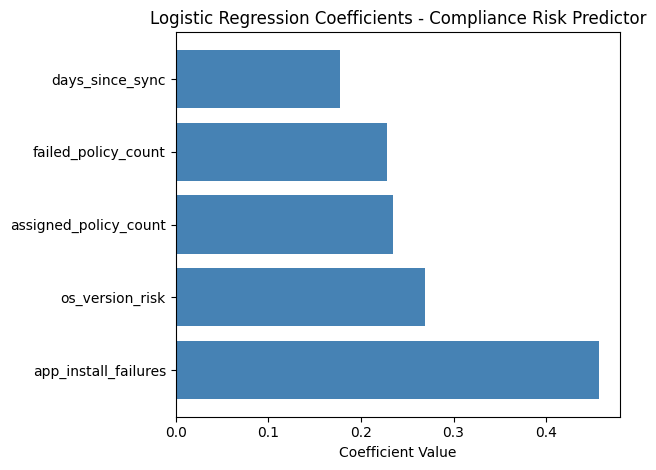

In [15]:
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients - Compliance Risk Predictor')
plt.tight_layout()
plt.show()